In [1]:
import copy
import importlib
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
import forecasting_utils

importlib.reload(forecasting_utils)

from forecasting_utils import (
    FOCUS_AGES,
    add_calendar_features,
    build_daily_arrivals,
    clean_opossum_data,
    evaluate_regression,
    forecast_date_range,
    save_csv,
)


# LSTM Modeling

This notebook compares three recurrent neural network architectures for daily opossum baby-arrival forecasting:

- `LSTM`
- `Bidirectional LSTM`
- `Stacked LSTM`

The models are trained on the proxy baby-arrival series derived from `opos_data.csv` using the same age-group definition as the rest of the project.


In [3]:
df = clean_opossum_data()
daily_df = build_daily_arrivals(df, focus_ages=FOCUS_AGES)

forecast_end_date = pd.Timestamp("2026-06-01")
observed_end_date = daily_df["admission_date"].max()
future_dates = forecast_date_range(observed_end_date, max(0, (forecast_end_date - observed_end_date).days))

sequence_length = 28
feature_cols = [
    "arrivals",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend",
    "is_holiday",
    "day_of_year",
]

train_end = pd.Timestamp("2024-12-31")
valid_end = pd.Timestamp("2025-12-31")

daily_df.tail()

,admission_date,arrivals,year,quarter,month,day,day_of_week,day_of_year,week_of_year,is_weekend,is_holiday,month_sin,month_cos,dow_sin,dow_cos
9502,2026-04-07,0,2026,2,4,7,1,97,15,0,0,0.866025,-0.5,0.781831,0.623490
9503,2026-04-08,0,2026,2,4,8,2,98,15,0,0,0.866025,-0.5,0.974928,-0.222521
9504,2026-04-09,0,2026,2,4,9,3,99,15,0,0,0.866025,-0.5,0.433884,-0.900969
9505,2026-04-10,0,2026,2,4,10,4,100,15,0,0,0.866025,-0.5,-0.433884,-0.900969
9506,2026-04-11,0,2026,2,4,11,5,101,15,1,0,0.866025,-0.5,-0.974928,-0.222521


In [4]:
def make_sequence_frame(df: pd.DataFrame, feature_cols: list[str], sequence_length: int) -> tuple[np.ndarray, np.ndarray, pd.Series]:
    values = df[feature_cols].to_numpy(dtype=float)
    targets = df["arrivals"].to_numpy(dtype=float)
    dates = pd.to_datetime(df["admission_date"]).reset_index(drop=True)

    X, y, sample_dates = [], [], []
    for idx in range(sequence_length, len(df)):
        X.append(values[idx - sequence_length:idx])
        y.append(targets[idx])
        sample_dates.append(dates.iloc[idx])

    return np.asarray(X), np.asarray(y), pd.Series(sample_dates, name="admission_date")


X_all, y_all, sample_dates = make_sequence_frame(daily_df, feature_cols, sequence_length)

train_mask = sample_dates <= train_end
valid_mask = (sample_dates > train_end) & (sample_dates <= valid_end)
test_mask = sample_dates > valid_end

feature_scaler = StandardScaler()
feature_scaler.fit(X_all[train_mask].reshape(-1, len(feature_cols)))

target_scaler = StandardScaler()
target_scaler.fit(y_all[train_mask].reshape(-1, 1))

def scale_sequences(X: np.ndarray) -> np.ndarray:
    flat = X.reshape(-1, len(feature_cols))
    scaled = feature_scaler.transform(flat)
    return scaled.reshape(X.shape)


X_train = scale_sequences(X_all[train_mask])
X_valid = scale_sequences(X_all[valid_mask])
X_test = scale_sequences(X_all[test_mask])

y_train = target_scaler.transform(y_all[train_mask].reshape(-1, 1)).ravel()
y_valid = target_scaler.transform(y_all[valid_mask].reshape(-1, 1)).ravel()
y_test = target_scaler.transform(y_all[test_mask].reshape(-1, 1)).ravel()

test_dates = sample_dates[test_mask].reset_index(drop=True)
valid_dates = sample_dates[valid_mask].reset_index(drop=True)

len(X_train), len(X_valid), len(X_test)

(9013, 365, 101)

In [5]:
train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1),
    ),
    batch_size=32,
    shuffle=True,
)

valid_inputs = torch.tensor(X_valid, dtype=torch.float32, device=device)
valid_targets = torch.tensor(y_valid, dtype=torch.float32, device=device).unsqueeze(-1)
test_inputs = torch.tensor(X_test, dtype=torch.float32, device=device)


In [6]:
class BaseLSTMRegressor(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int = 1, bidirectional: bool = False, dropout: float = 0.0):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=lstm_dropout,
        )
        output_size = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.Linear(output_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        last_hidden = output[:, -1, :]
        return self.head(last_hidden)


model_configs = {
    "LSTM": {"hidden_size": 32, "num_layers": 1, "bidirectional": False, "dropout": 0.0},
    "Bidirectional LSTM": {"hidden_size": 32, "num_layers": 1, "bidirectional": True, "dropout": 0.0},
    "Stacked LSTM": {"hidden_size": 32, "num_layers": 2, "bidirectional": False, "dropout": 0.2},
}


def train_model(model: nn.Module, train_loader: DataLoader, valid_inputs: torch.Tensor, valid_targets: torch.Tensor, epochs: int = 80, patience: int = 10, lr: float = 1e-3) -> tuple[nn.Module, pd.DataFrame]:
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_state = copy.deepcopy(model.state_dict())
    best_valid_loss = float("inf")
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch_inputs, batch_targets in train_loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()
            predictions = model(batch_inputs)
            loss = criterion(predictions, batch_targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(batch_inputs)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            valid_predictions = model(valid_inputs)
            valid_loss = criterion(valid_predictions, valid_targets).item()

        history.append({"epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss})

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def inverse_target(values: np.ndarray) -> np.ndarray:
    return target_scaler.inverse_transform(values.reshape(-1, 1)).ravel()


def predict_model(model: nn.Module, X_scaled: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_scaled, dtype=torch.float32, device=device)).cpu().numpy().ravel()
    return np.clip(inverse_target(preds), 0.0, None)


def recursive_forecast_lstm(model: nn.Module, history_df: pd.DataFrame, future_dates: pd.DatetimeIndex, feature_cols: list[str], sequence_length: int) -> pd.DataFrame:
    history = history_df.copy()
    future_rows = []

    for forecast_date in future_dates:
        row = add_calendar_features(pd.DataFrame({"admission_date": [forecast_date], "arrivals": [np.nan]}))
        row["arrivals"] = np.nan
        candidate = pd.concat([history, row], ignore_index=True)
        seq = candidate[feature_cols].tail(sequence_length).copy()
        seq.loc[seq["arrivals"].isna(), "arrivals"] = 0.0
        seq_scaled = feature_scaler.transform(seq.to_numpy(dtype=float)).reshape(1, sequence_length, len(feature_cols))
        pred = predict_model(model, seq_scaled)[0]
        row["arrivals"] = pred
        history = pd.concat([history, row], ignore_index=True)
        future_rows.append(row)

    if not future_rows:
        return pd.DataFrame(columns=history.columns)

    return pd.concat(future_rows, ignore_index=True)


def first_arrival_distribution(prediction_df: pd.DataFrame, prediction_col: str) -> pd.DataFrame:
    out = prediction_df[["admission_date", prediction_col]].copy()
    lambda_values = out[prediction_col].clip(lower=0).to_numpy(dtype=float)
    survival_before = np.exp(-np.cumsum(np.r_[0.0, lambda_values[:-1]]))
    out["first_arrival_probability"] = survival_before * (1 - np.exp(-lambda_values))
    out["cumulative_arrival_probability"] = out["first_arrival_probability"].cumsum()
    return out


## Train And Compare Models

In [7]:
model_results = []
training_histories = {}
observed_predictions = pd.DataFrame({"admission_date": test_dates, "arrivals": y_all[test_mask]})
future_predictions = pd.DataFrame({"admission_date": future_dates})
trained_models = {}

for model_name, config in model_configs.items():
    model = BaseLSTMRegressor(input_size=len(feature_cols), **config)
    trained_model, history = train_model(model, train_loader, valid_inputs, valid_targets)
    training_histories[model_name] = history
    trained_models[model_name] = trained_model

    valid_pred = predict_model(trained_model, X_valid)
    test_pred = predict_model(trained_model, X_test)

    valid_metrics = evaluate_regression(y_all[valid_mask], valid_pred, f"{model_name} validation")
    test_metrics = evaluate_regression(y_all[test_mask], test_pred, f"{model_name} test")

    model_results.append(
        {
            "model": model_name,
            "validation_mae": valid_metrics["mae"],
            "validation_rmse": valid_metrics["rmse"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
            "test_mape": test_metrics["mape"],
        }
    )

    observed_predictions[f"{model_name}_pred"] = test_pred

    future_rows = recursive_forecast_lstm(trained_model, daily_df, future_dates, feature_cols, sequence_length)
    future_predictions[f"{model_name}_pred"] = future_rows["arrivals"].to_numpy() if not future_rows.empty else np.array([])

metrics_df = pd.DataFrame(model_results).sort_values(["test_rmse", "test_mae"])
metrics_df

,model,validation_mae,validation_rmse,test_mae,test_rmse,test_mape
1,Bidirectional LSTM,1.804518,3.358658,0.118291,0.510726,97.127158
2,Stacked LSTM,1.879731,3.426688,0.152364,0.512716,96.259803
0,LSTM,1.741232,3.251073,0.133649,0.517617,95.755267


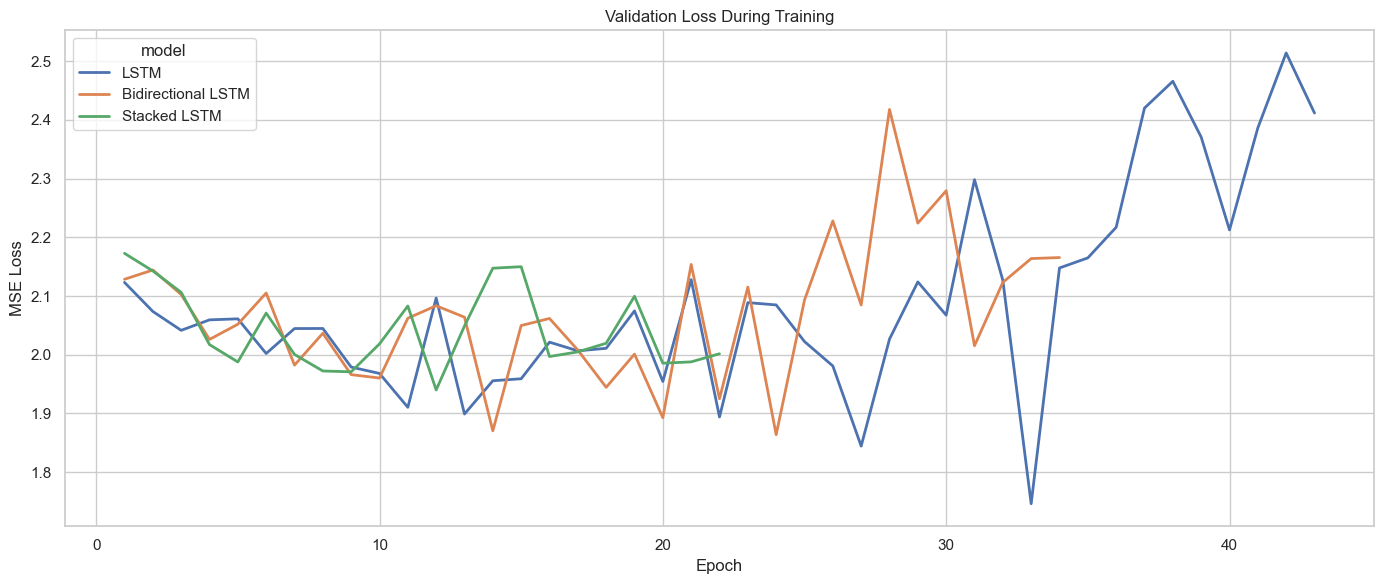

In [8]:
history_long = pd.concat(
    [history.assign(model=model_name) for model_name, history in training_histories.items()],
    ignore_index=True,
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=history_long, x="epoch", y="valid_loss", hue="model", linewidth=2)
plt.title("Validation Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.show()

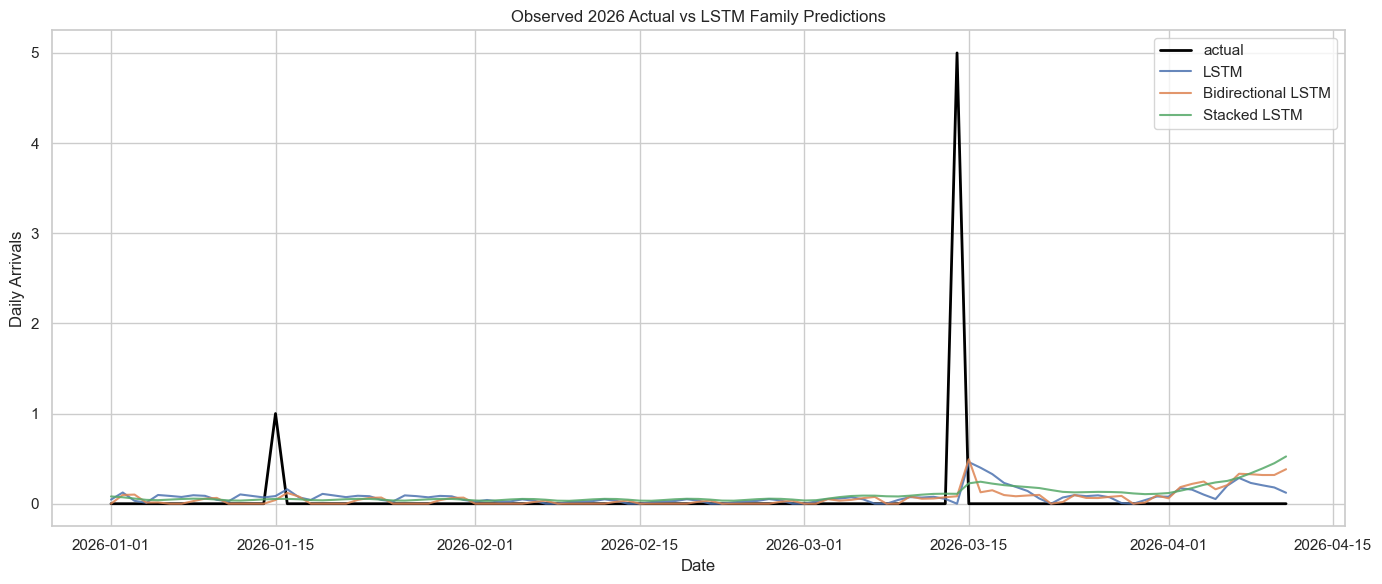

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(observed_predictions["admission_date"], observed_predictions["arrivals"], label="actual", linewidth=2, color="black")
for model_name in model_configs:
    plt.plot(observed_predictions["admission_date"], observed_predictions[f"{model_name}_pred"], label=model_name, alpha=0.85)
plt.title("Observed 2026 Actual vs LSTM Family Predictions")
plt.xlabel("Date")
plt.ylabel("Daily Arrivals")
plt.legend()
plt.tight_layout()
plt.show()

## Future Forecast Through June 1

In [10]:
lstm_predictions = pd.concat([observed_predictions, future_predictions.assign(arrivals=np.nan)], ignore_index=True)
lstm_predictions.tail(15)

,admission_date,arrivals,LSTM_pred,Bidirectional LSTM_pred,Stacked LSTM_pred
137,2026-05-18,NaN,2.504704,4.437176,4.239397
138,2026-05-19,NaN,2.849659,4.258055,4.306620
139,2026-05-20,NaN,2.450760,4.208696,4.658850
140,2026-05-21,NaN,2.458011,4.084244,5.069983
141,2026-05-22,NaN,2.501373,4.387052,5.273814
142,2026-05-23,NaN,1.780329,5.568031,5.094865
143,2026-05-24,NaN,1.271721,4.874904,4.653877
144,2026-05-25,NaN,1.670228,3.904174,4.393752
145,2026-05-26,NaN,2.118084,4.055078,4.470612
146,2026-05-27,NaN,2.052032,4.022100,4.793120


## First Arrival Timing After The Last Observed Date

In [11]:
future_only = lstm_predictions.loc[lstm_predictions["arrivals"].isna()].copy()

first_arrival_frames = []
first_arrival_summary = []

for model_name in model_configs:
    dist = first_arrival_distribution(future_only, f"{model_name}_pred")
    dist["model"] = model_name
    first_arrival_frames.append(dist)

    peak_row = dist.loc[dist["first_arrival_probability"].idxmax()]
    first_arrival_summary.append(
        {
            "model": model_name,
            "most_likely_first_arrival_date": peak_row["admission_date"],
            "peak_first_arrival_probability": peak_row["first_arrival_probability"],
            "probability_arrival_by_horizon": dist["cumulative_arrival_probability"].iloc[-1] if not dist.empty else 0.0,
        }
    )

first_arrival_long = pd.concat(first_arrival_frames, ignore_index=True)
first_arrival_summary = pd.DataFrame(first_arrival_summary).sort_values("peak_first_arrival_probability", ascending=False)
first_arrival_summary

,model,most_likely_first_arrival_date,peak_first_arrival_probability,probability_arrival_by_horizon
2,Stacked LSTM,2026-04-12,0.378720,1.0
1,Bidirectional LSTM,2026-04-12,0.278046,1.0
0,LSTM,2026-04-13,0.236839,1.0


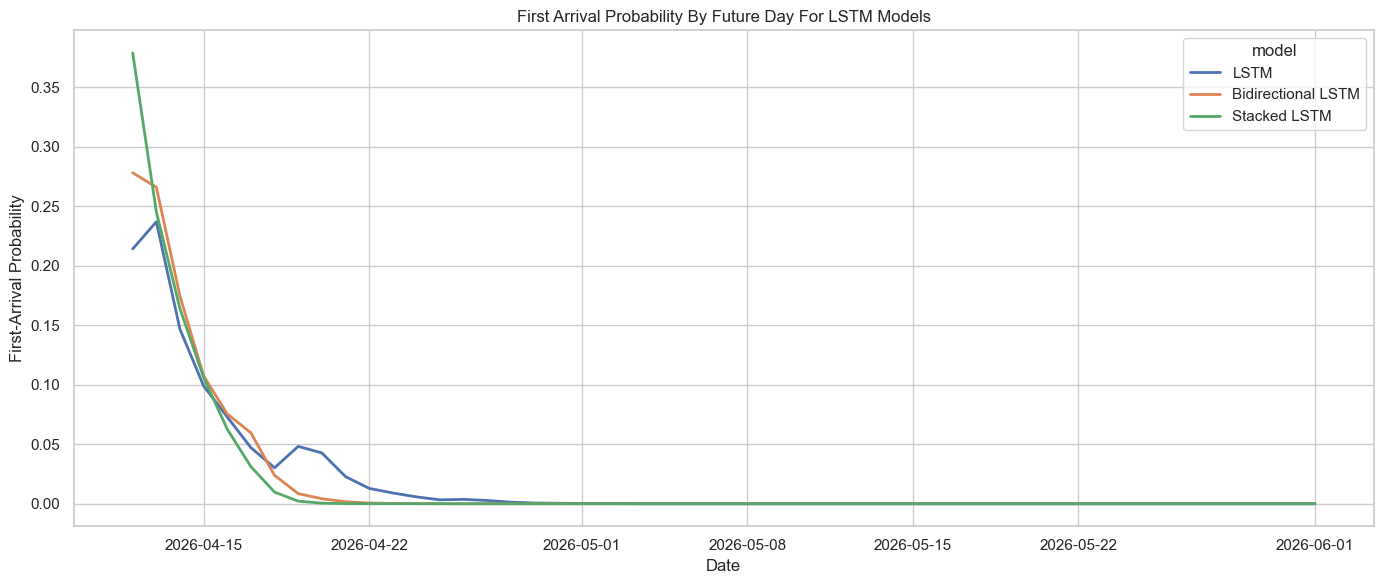

In [12]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=first_arrival_long,
    x="admission_date",
    y="first_arrival_probability",
    hue="model",
    linewidth=2,
)
plt.title("First Arrival Probability By Future Day For LSTM Models")
plt.xlabel("Date")
plt.ylabel("First-Arrival Probability")
plt.tight_layout()
plt.show()

In [13]:
save_csv(metrics_df, "lstm_model_metrics.csv")
save_csv(lstm_predictions, "lstm_model_predictions.csv")
save_csv(first_arrival_summary, "lstm_first_arrival_summary.csv")

WindowsPath('C:/Users/Owner/PycharmProjects/opos_prediction/data/processed/lstm_first_arrival_summary.csv')